In [1]:
#autoreload
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import numpy as np
import featureman.gen_data as man
import featureman.utils as utils
from sklearn.cluster import SpectralClustering
import pickle
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
model_dict = torch.load("multi_layer_modular_arithmetic_model.pth", map_location=device)
model = man.MultiLayerTransformer(p=113, d_model=128, n_layers=3).to(device)
model.load_state_dict(model_dict)

<All keys matched successfully>

In [3]:
torch.manual_seed(1337)
# generate combination of all inputs a and b range (113)
a_values = np.arange(113)
b_values = np.arange(113)
# generate inputs for the model
inputs = np.array([[a_i, 113, b_i, 114] for a_i in a_values for b_i in b_values])
inputs = torch.tensor(inputs).to(device)  # Add batch dimension

logits, activations = model(inputs, return_activations=True)

In [10]:
layer1_acts = activations[0][:,-1,:].detach().cpu().numpy()
layer2_acts = activations[1][:,-1,:].detach().cpu().numpy()
layer3_acts = activations[2][:,-1,:].detach().cpu().numpy()
layer1_acts.shape

(12769, 512)

In [11]:
mod_additions = inputs[:, 0] + inputs[:, 2]
mod_additions = mod_additions % 113

In [12]:
mod_additions = mod_additions.cpu().numpy()

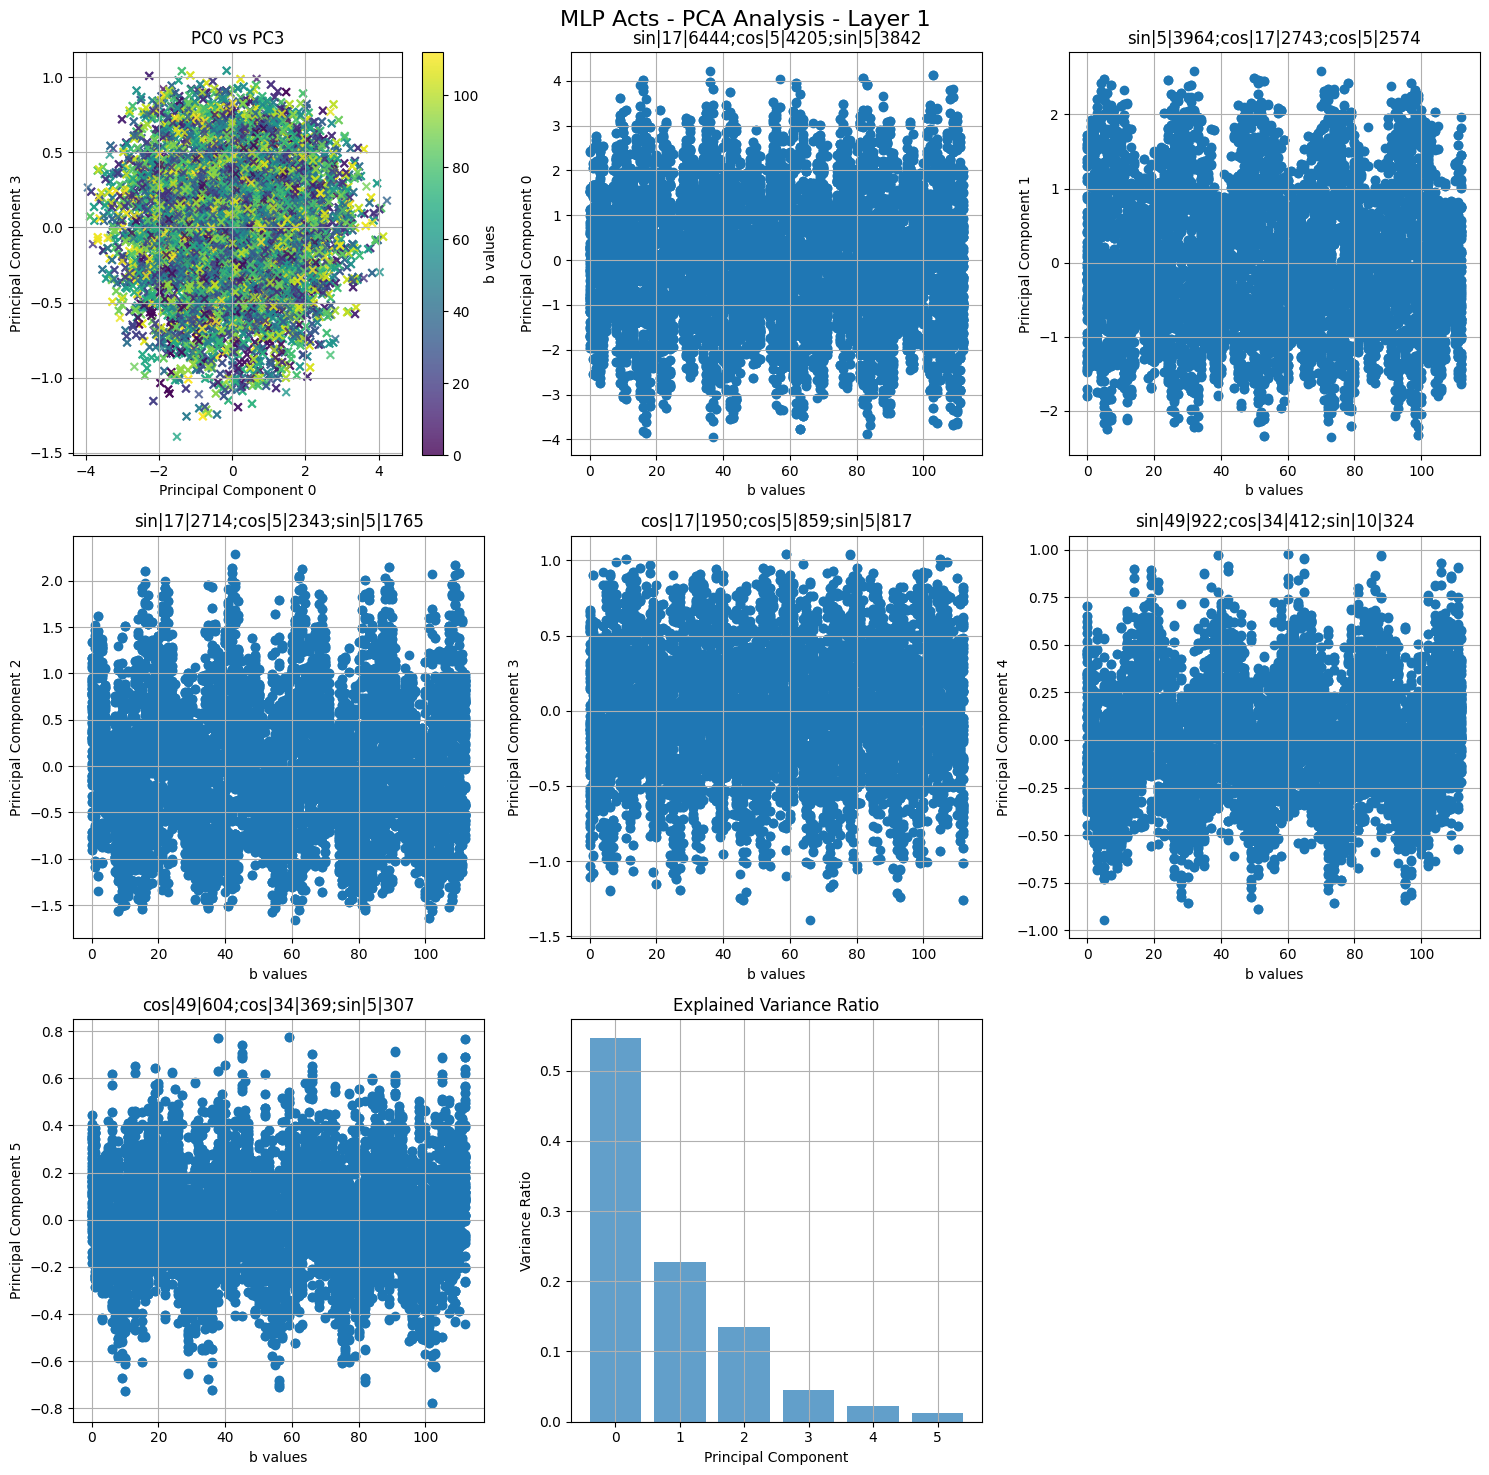

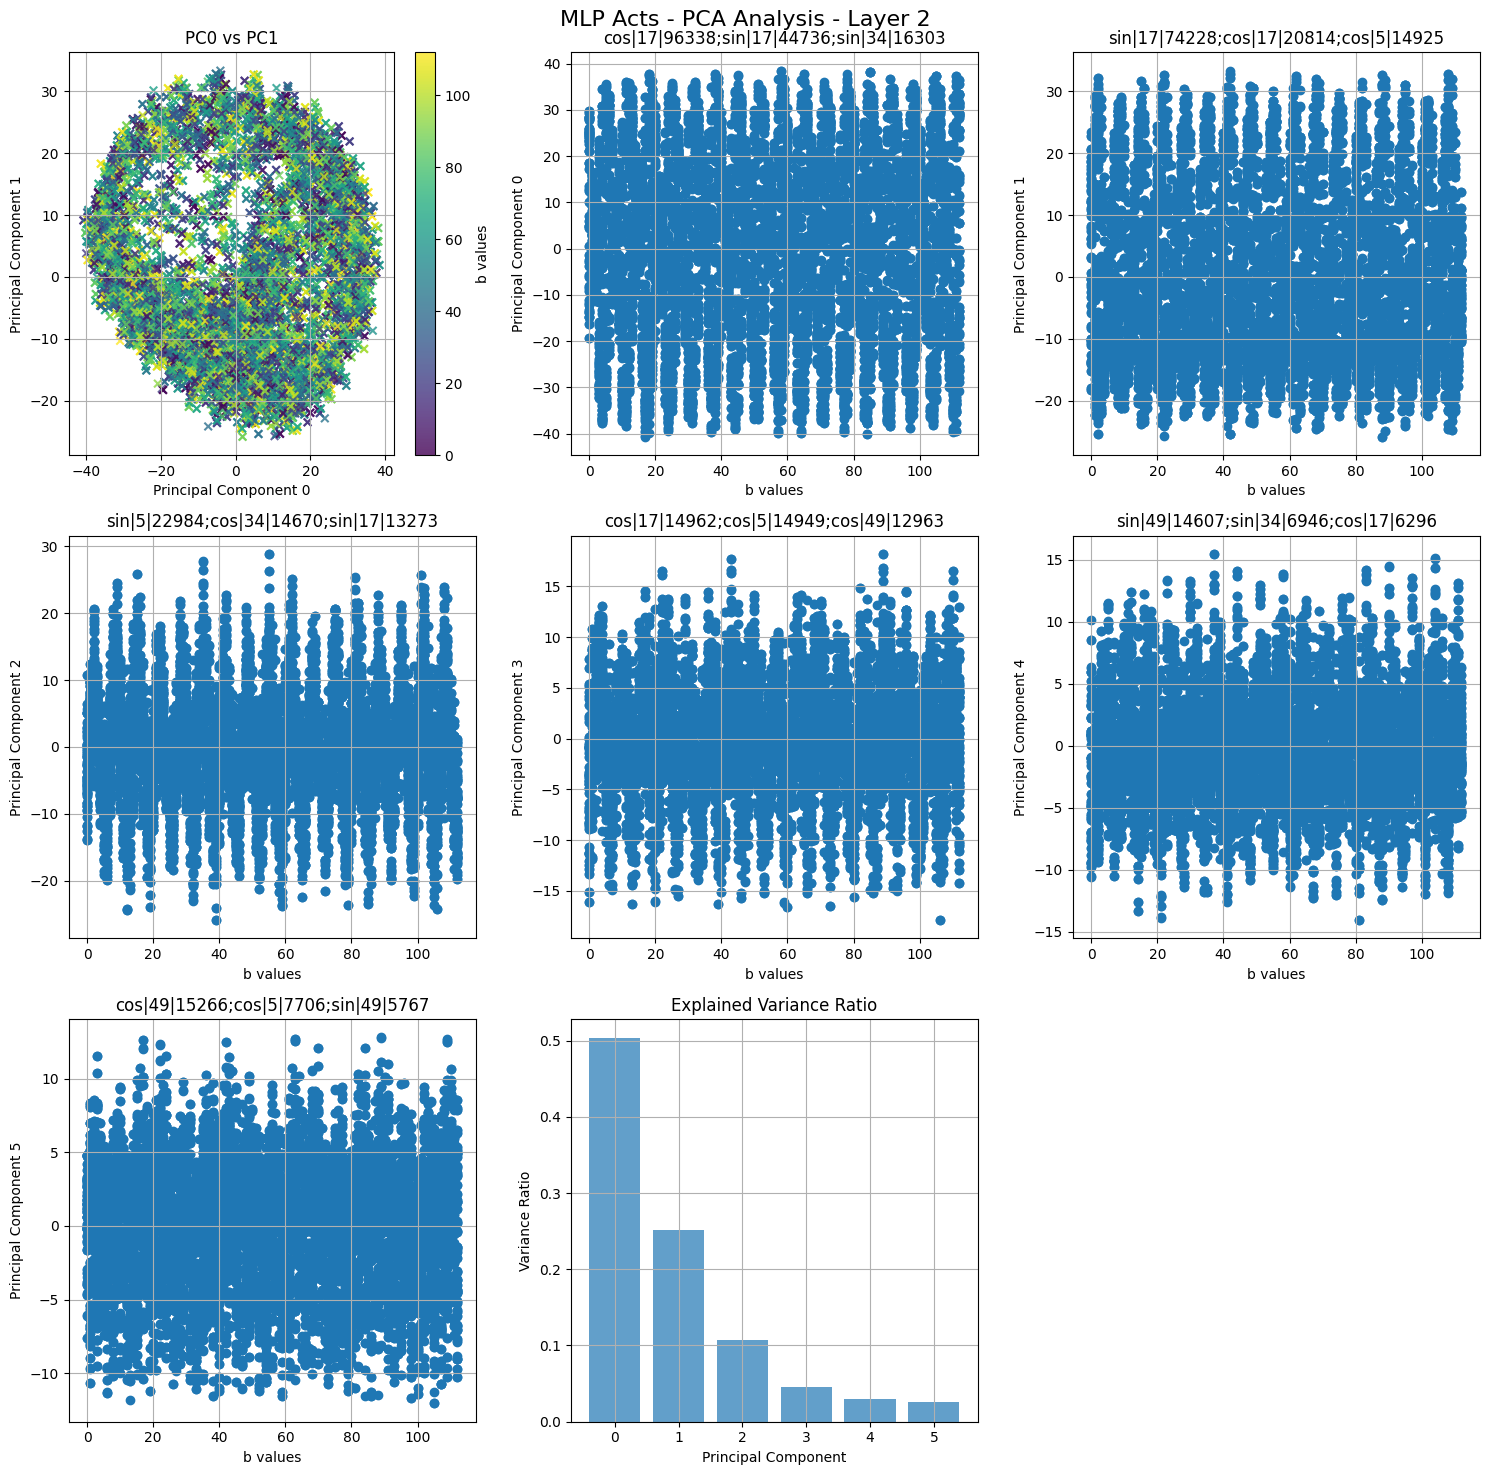

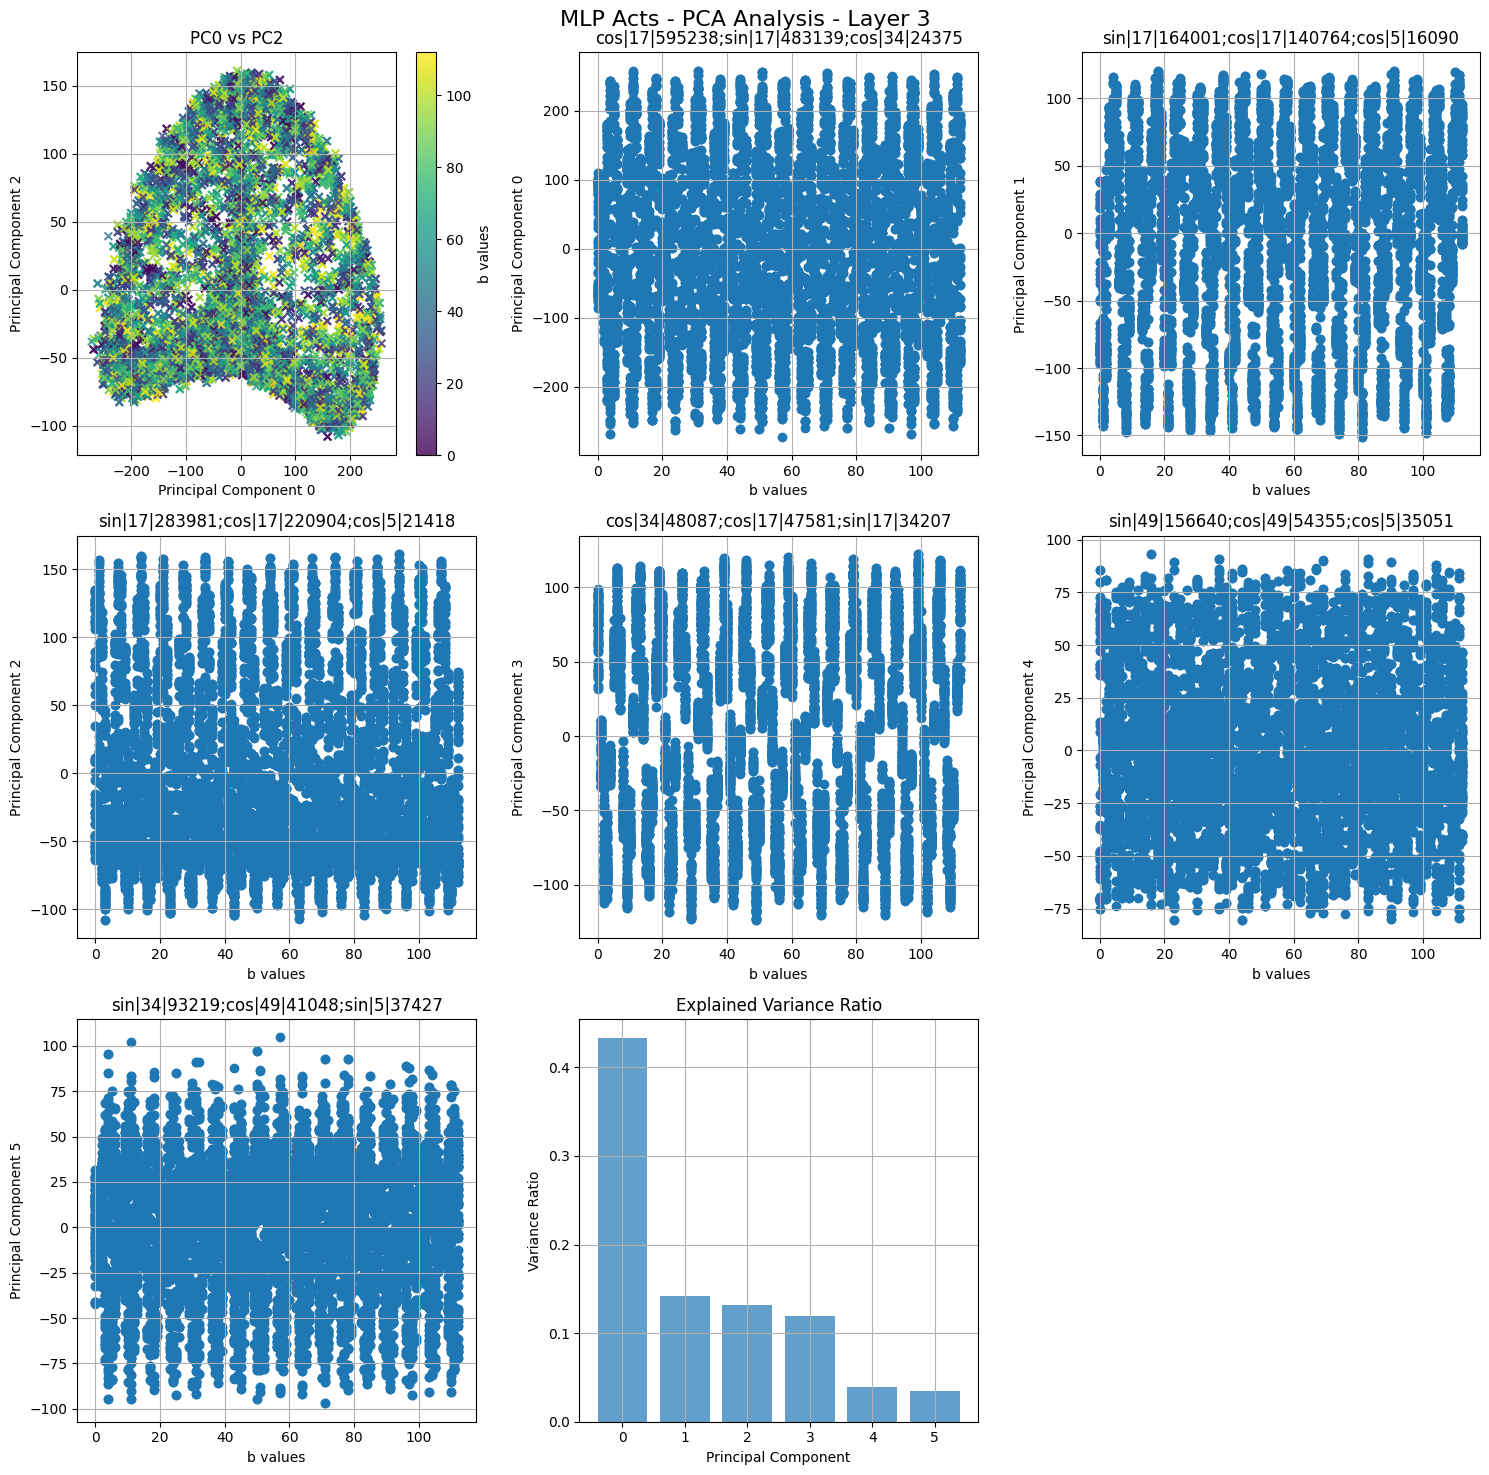

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

for j in range(3):
    plt.figure(figsize=(15, 15))
    #mlp truth
    pca = PCA(n_components=6).fit(activations[j][:,-1,:].detach().cpu().numpy())
    output_pca = pca.transform(activations[j][:,-1,:].detach().cpu().numpy())

    top_freqs = utils.plot_pca_fourier_components(output_pca, plot=False)

    if j == 0:
        x = 3
    elif j == 1:
        x = 1
    elif j == 2:
        x = 2
    plt.subplot(3, 3, 1)
    scatter = plt.scatter(output_pca[:, 0][:], output_pca[:, x][:], marker='x', c=mod_additions[:], s=30, alpha=0.8, cmap='viridis')
    plt.title(f"PC0 vs PC{x}")
    plt.xlabel("Principal Component 0")
    plt.ylabel(f"Principal Component {x}")
    plt.grid()
    plt.colorbar(scatter, label='b values')

    for i in range(6):

        plt.subplot(3, 3, 2 + i)
        plt.scatter(mod_additions[:], output_pca[:, i][:], marker='o')
        plt.title(";".join(f"{freq['type']}|{freq['frequency']}|{int(freq['magnitude'])}" 
                        for freq in top_freqs[i][:3]))
        plt.xlabel("b values")
        plt.ylabel(f"Principal Component {i}")
        plt.grid()


    #explained variance bar plot
    plt.subplot(3, 3, 8)
    plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_, alpha=0.7)
    plt.title("Explained Variance Ratio")
    plt.xlabel("Principal Component")
    plt.ylabel("Variance Ratio")
    plt.xticks(range(len(pca.explained_variance_ratio_)))
    plt.grid()

    plt.suptitle(f"MLP Acts - PCA Analysis - Layer {j+1}", fontsize=16)

    plt.tight_layout()
    plt.show()
